# Muon on conv is not Muon

In this notebook we will show the discrepancy between the theoretical framework and what is done in practice when muon is applied on convolutions.

# part 0: What does Muon do on linear matrices ?

## 0.1 Muon theory is based on the polar factorization of updates (what Muon does for linear matrices):

The muon algorithm is in fact quite simple:

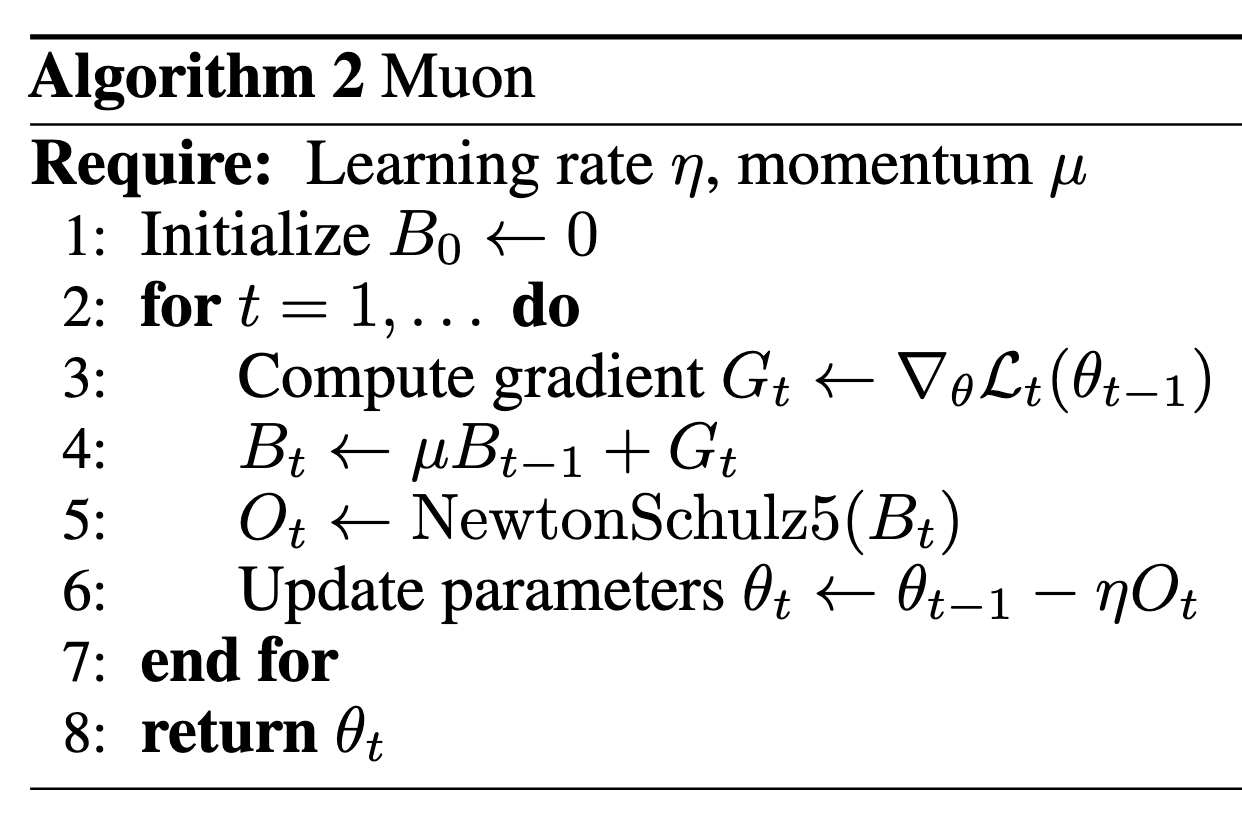

I won't get into the theory here but you can read https://arxiv.org/abs/2409.20325 to understand why performing the polar factorization is so efficient.

### But what the hell is a polar factor?

To understand what the polar factor is, you must first know about *orthogonal matrices*. There matrices fullfill this definition:

$$ MM^t = I $$
$$ M^tM = I $$

When the matrix is square, both properties must be fullfiled, otherwise only one should be fullfilled (and the matrix is said pseudo orthogonal).

The polar factor of a matrix is an orthogonal matrix. But not any orthogonal matrix, it shoudl be the **closest orthogonal matrix to the original** gradient.

If you are aware of singular it can be computed with svd:

$$ M = U\Sigma V^T \rightarrow \text{PolarFactor}(M) = UV^T $$

In practice this is quite expensive to compute, so a fast, and GPU-friendly algorithm is used to approximate it quickly:

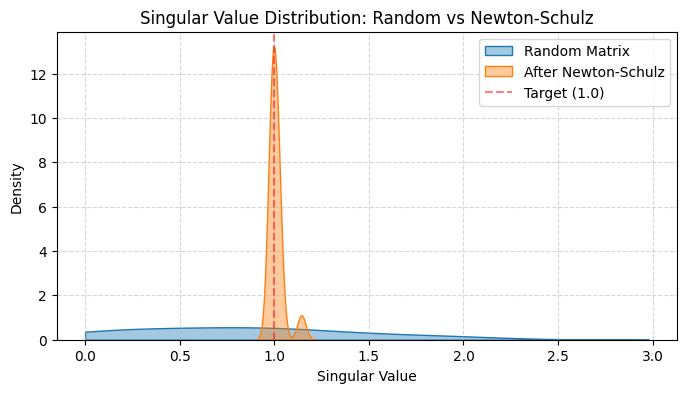

In [47]:
def newton_schulz(
    G, iter=5, precondition=False, epsilon: float = 1e-7, dtype=torch.float32
):
    """
    Newton-Schulz iteration to compute the zeroth power / orthogonalization of G. We opt to use a
    quintic iteration whose coefficients are selected to maximize the slope at zero. For the purpose
    of minimizing steps, it turns out to be empirically effective to keep increasing the slope at
    zero even beyond the point where the iteration no longer converges all the way to one everywhere
    on the interval. This iteration therefore does not produce UV^T but rather something like US'V^T
    where S' is diagonal with S_{ii}' ~ Uniform(0.5, 1.5), which turns out not to hurt model
    performance at all relative to UV^T, where USV^T = G is the SVD.
    """
    assert G.ndim >= 2
    ns_consts = [
        (4.0848, -6.8946, 2.9270),
        (3.9505, -6.3029, 2.6377),
        (3.7418, -5.5913, 2.3037),
        (2.8769, -3.1427, 1.2046),
        (2.8366, -3.0525, 1.2012),
    ][-iter:]
    X = G.to(dtype=dtype).clone()
    if G.size(-2) > G.size(-1):
        X = X.mT

    if not precondition:
        X /= X.norm(dim=(-2, -1), keepdim=True) + epsilon

    # Perform the NS iterations
    for i, (a, b, c) in enumerate(ns_consts):
        A = X @ X.mT
        if precondition and i == 0:
            s = torch.rsqrt(
                torch.clamp_min(A.abs().sum(dim=-1, keepdim=False), min=epsilon)
            )
            X = X * s.unsqueeze(-1)
            A = A * s.unsqueeze(-1) * s.unsqueeze(-2)

        B = (
            b * A + c * A @ A
        )  # quintic computation strategy adapted from suggestion by @jxbz, @leloykun, and @YouJiacheng
        X = a * X + B @ X

    if G.size(-2) > G.size(-1):
        X = X.mT
    return X


# Sample a random matrix
rand_mat = torch.randn(16, 16, device=device) * 0.25

# Apply Newton-Schulz orthogonalization
ns_mat = newton_schulz(rand_mat)

# Compute singular values
sv_rand = torch.linalg.svdvals(rand_mat).cpu().numpy()
sv_ns = torch.linalg.svdvals(ns_mat).cpu().numpy()

# Plot KDE of singular values
plt.figure(figsize=(8, 4))
sns.kdeplot(sv_rand, label="Random Matrix", fill=True, alpha=0.4, clip=(0, 3))
sns.kdeplot(sv_ns, label="After Newton-Schulz", fill=True, alpha=0.4, clip=(0, 3))
plt.axvline(1.0, color="red", linestyle="--", alpha=0.5, label="Target (1.0)")
plt.title("Singular Value Distribution: Random vs Newton-Schulz")
plt.xlabel("Singular Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

For the intested reader, accelerated variants are availble in theses papers:
- https://arxiv.org/abs/2505.16932 and https://arxiv.org/abs/2506.10935 shows how to find optimal factors for faster convergence
- https://github.com/microsoft/dion contains a highly efficient implementation that leverage symmetries in the algorithm
- https://arxiv.org/abs/2512.04632 use preconditionning to improve the algorithm in the low iteration regime.

## part 1: What make convolutions different ? A Block circulant perspective



In [48]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

## 1.1 Convolutions are not so different: linear operators with Block circulant Structure

We can explicitely construct the dense matrix equivalent to the convolution operator 

In [49]:
def to_block_circulant(kernel, img_shape):
    # fixing seeds for reproducibility
    layer = torch.nn.Conv2d(
        in_channels=kernel.shape[1],
        out_channels=kernel.shape[0],
        kernel_size=kernel.shape[-2:],
        padding=kernel.shape[-2] // 2,
        padding_mode="zeros",
    )
    layer.weight.data = kernel
    layer.bias.data = torch.zeros(kernel.shape[0])
    torch.manual_seed(0)
    np.random.seed(0)
    with torch.no_grad():
        layer = layer.to(device)
        inputs = (
            torch.eye(img_shape[0] * img_shape[1] * img_shape[2])
            .view(
                img_shape[0] * img_shape[1] * img_shape[2],
                img_shape[0],
                img_shape[1],
                img_shape[2],
            )
            .to(device)
        )
        outputs = layer(inputs)
        outputs_reshaped = outputs.view(outputs.shape[0], -1)
    return outputs_reshaped.cpu()

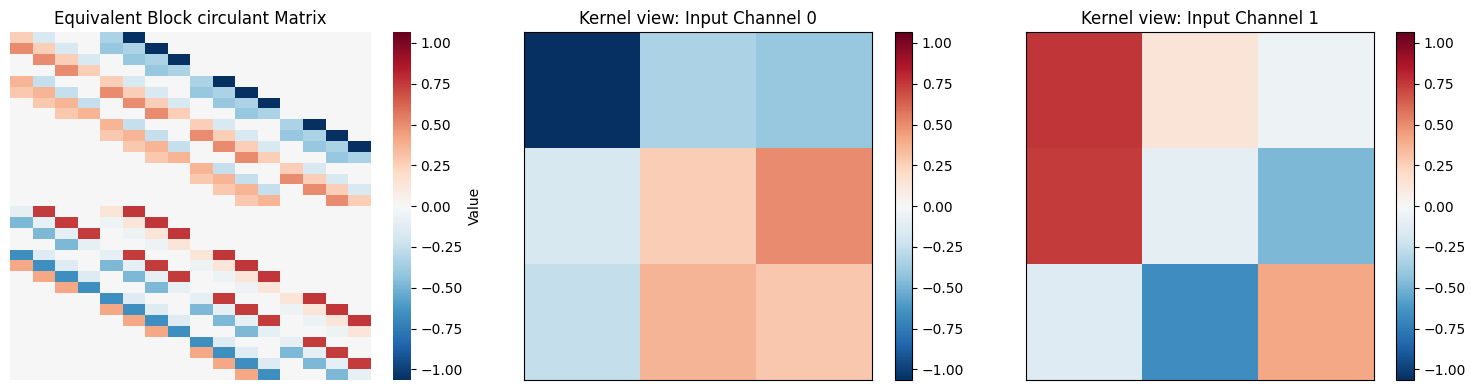

In [50]:
cout = 1
cin = 2
kh, kw = (3, 3)
kernel = torch.randn((cout, cin, kh, kw)).float() * 0.5  # (cout, cin, kh, kw)

# torch.tensor([[[1,2,3],[4,5,6],[7,8,9]], [[-1,-2,-3],[-4,-5,-6],[-7,-8,-9]]]).float().unsqueeze(0)  # (cout=1, cin=1, kh=3, kw=3)

img_shape = (2, 4, 4)

toplitz_equiv = to_block_circulant(kernel, img_shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot Block circulant matrix
v = abs(toplitz_equiv).max()
sns.heatmap(toplitz_equiv, cmap="RdBu_r", vmin=-v, vmax=v, center=0, ax=axes[0], cbar_kws={'label': 'Value'})
axes[0].set_title('Equivalent Block circulant Matrix')
# axes[0].set_xlabel('Columns')
# axes[0].set_ylabel('Rows')
axes[0].set_xticks([])
axes[0].set_yticks([])

# Plot each input channel filter
for c in range(cin):
    axes[c+1].imshow(kernel[0, c].cpu().numpy(), cmap='RdBu_r', vmin=-v, vmax=v)
    axes[c+1].set_title(f'Kernel view: Input Channel {c}')
    # axes[c+1].set_xlabel('Width')
    # axes[c+1].set_ylabel('Height')
    axes[c+1].set_xticks([])
    axes[c+1].set_yticks([])
    plt.colorbar(axes[c+1].images[0], ax=axes[c+1])

plt.tight_layout()
plt.show()

- Note 1: the matrix is much larger than the kernel ! for an 32x32 image with 64 channels it would be a matrix with (32x32x64x64)^2 entries !

- Note 2: the Block circulant is very sparse. Beyon the Block circulant aspect, this sparsity pattern is very important: it is the signature of a 3x3 kernel. For instance a 5x5 kernel would have larger bands!

## 1.2 What muon does: reshaping the kernel before orthogonalization

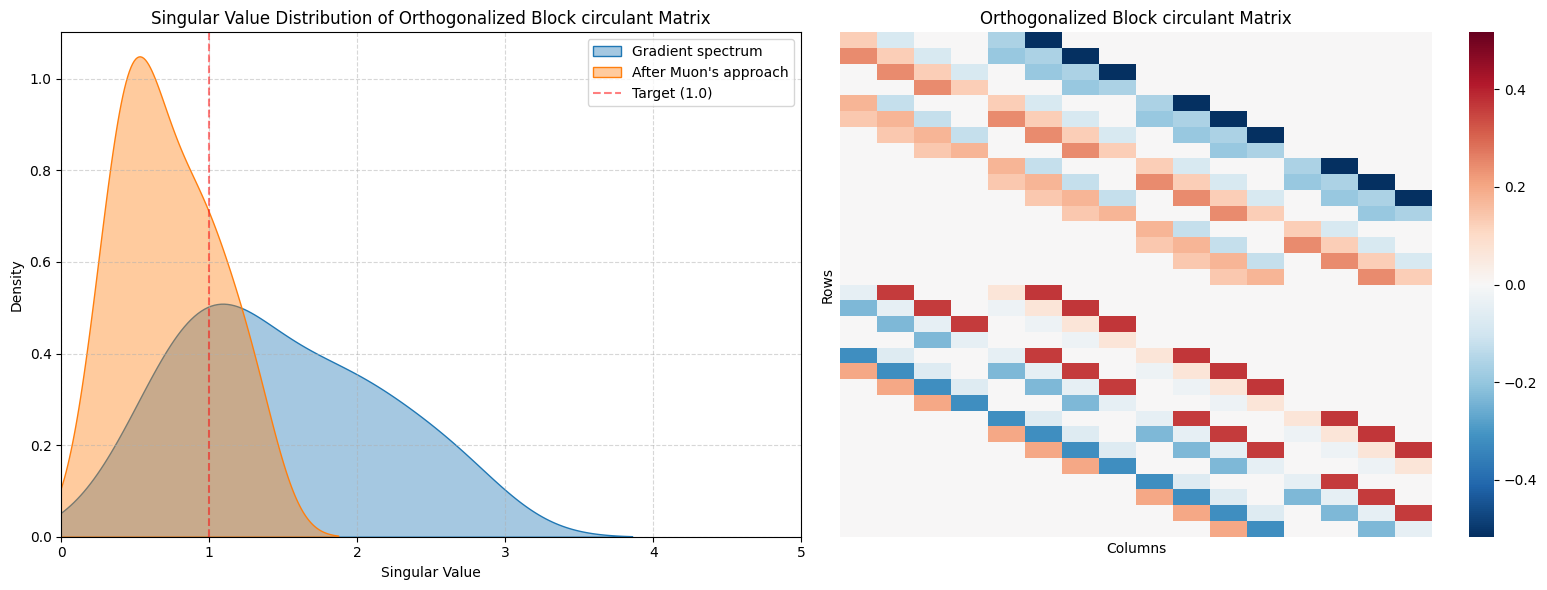

In [51]:
orthogonalized_kernel = newton_schulz(kernel.view(cout, -1)).view(cout, cin, kh, kw)
orthogonalized_toplitz = to_block_circulant(orthogonalized_kernel, img_shape)

# Compute singular values of the orthogonalized Block circulant matrix
svd_vals_original = torch.linalg.svdvals(toplitz_equiv).cpu().numpy()
svd_vals_muon = torch.linalg.svdvals(orthogonalized_toplitz).cpu().numpy()
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Left: Singular value distribution
sns.kdeplot(
    svd_vals_original, fill=True, alpha=0.4, label="Gradient spectrum", ax=axs[0]
)
sns.kdeplot(
    svd_vals_muon, fill=True, alpha=0.4, label="After Muon's approach", ax=axs[0]
)
axs[0].axvline(1.0, color="red", linestyle="--", alpha=0.5, label="Target (1.0)")
axs[0].set_xlim(0, 5)
axs[0].set_title("Singular Value Distribution of Orthogonalized Block circulant Matrix")
axs[0].set_xlabel("Singular Value")
axs[0].set_ylabel("Density")
axs[0].legend()
axs[0].grid(True, linestyle="--", alpha=0.5)

# Right: Heatmap of orthogonalized Block circulant matrix

v = abs(orthogonalized_toplitz).max()
sns.heatmap(orthogonalized_toplitz, cmap="RdBu_r", vmin=-v, vmax=v, center=0, ax=axs[1])
axs[1].set_title("Orthogonalized Block circulant Matrix")
axs[1].set_xlabel("Columns")
axs[1].set_ylabel("Rows")
axs[1].set_xticks([])
axs[1].set_yticks([])

plt.tight_layout()
plt.show()

OK! We see that the current approach does not gives a orthonormal operator! This highlights a fundamental divergence between what muon really does on convolutions and what it should do!

## 1.3 Exact Muon: Applying Polar decomposition to convolutions

Now that we know we can convert convolution to equivalent Block circulant matrix, we can try to do what Muon should theoretically do: replace the update matrix by its polar factor ! 

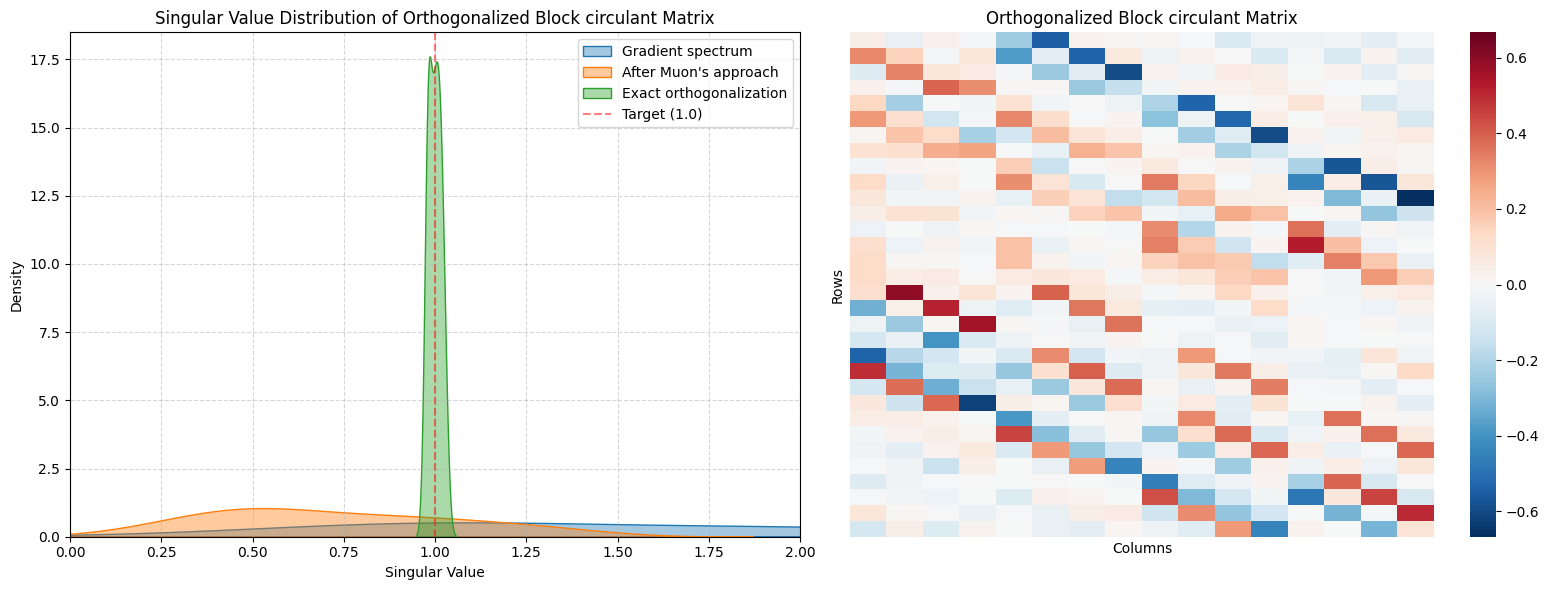

In [52]:
orthogonalized_toplitz = newton_schulz(toplitz_equiv)

# Compute singular values of the orthogonalized Block circulant matrix
svd_vals_exact = torch.linalg.svdvals(orthogonalized_toplitz).cpu().numpy()

# # Plot the distribution of singular values
# fig = plt.figure(figsize=(8, 4))
# sns.kdeplot(svd_vals_original, fill=True, alpha=0.4, label="Gradient spectrum")
# sns.kdeplot(svd_vals_muon, fill=True, alpha=0.4, label="After Muon's approach")
# sns.kdeplot(svd_vals_exact, fill=True, alpha=0.4, label="Exact orthogonalization")
# plt.axvline(1.0, color="red", linestyle="--", alpha=0.5, label="Target (1.0)")
# fig.axes[0].set_xlim(0, 2)
# plt.title("Singular Value Distribution of Orthogonalized Block circulant Matrix")
# plt.xlabel("Singular Value")
# plt.ylabel("Density")
# plt.legend()
# plt.grid(True, linestyle="--", alpha=0.5)
# plt.show()

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Left: Singular value distribution
sns.kdeplot(
    svd_vals_original, fill=True, alpha=0.4, label="Gradient spectrum", ax=axs[0]
)
sns.kdeplot(
    svd_vals_muon, fill=True, alpha=0.4, label="After Muon's approach", ax=axs[0]
)
sns.kdeplot(
    svd_vals_exact, fill=True, alpha=0.4, label="Exact orthogonalization", ax=axs[0]
)
axs[0].axvline(1.0, color="red", linestyle="--", alpha=0.5, label="Target (1.0)")
axs[0].set_xlim(0, 2)
axs[0].set_title("Singular Value Distribution of Orthogonalized Block circulant Matrix")
axs[0].set_xlabel("Singular Value")
axs[0].set_ylabel("Density")
axs[0].legend()
axs[0].grid(True, linestyle="--", alpha=0.5)

# Right: Heatmap of orthogonalized Block circulant matrix

v = abs(orthogonalized_toplitz).max()
sns.heatmap(orthogonalized_toplitz, cmap="RdBu_r", vmin=-v, vmax=v, center=0, ax=axs[1])
axs[1].set_title("Orthogonalized Block circulant Matrix")
axs[1].set_xlabel("Columns")
axs[1].set_ylabel("Rows")
axs[1].set_xticks([])
axs[1].set_yticks([])

plt.tight_layout()
plt.show()

Uh oh. We are in trouble: We fixed the spectrum issue, but this completely broke the Block circulant sparity! We can't convert it back to a nice 3x3 convolution! Since we used the svd, this is not a result of numerical approximation.

**This means that orthogonalization is non-trivial for convolutions**

To get a closer look you can read this paper: https://www.jmlr.org/papers/v23/22-0026.html . In this paper you'd learn two things:
1. There are no orthogonal convolution with stride greated than the kernel size.
2. There are no orthogonal convolution with zero padding and kernel size greater than 1. Hopefully this is not the case for circular padding.
3. The orthogonalization does not break the Block circulant structure, it only breaks the sparsity (more clearly said in  https://theses.hal.science/tel-04122195v1 )

The theory behind muon seems compliant with computing the polar factor of the convolution "as if it was using circular padding": the resulting constraint is slightly pessimistic du the image borders.

**We must find a principled definition of the Polar factor for convolution**

We propose the following definition:
1. the polar factor must be orthogonal, once we assumed a circular padding. This allows for a definition as close as possible to muons theory.
2. the polar factor must respect the sparsity pattern. This ensure that the polar factor of the update has the same size as the kernel weight.
3. the polar factor must be as close as possible to the original kernel.

The solution of our problem must lie at the intersection of the two manifolds (kxk kernels and orthogonal convolutions).

# Our approach: convolutional Newton-Schulz

## 2.0 General Idea of the algorithm: Alternate projections

We have two constraints: we must be kxk block circulant and we also want to be orthonormal. The algorithm we introduce draw its inspiration from the alternate projection algorithm.

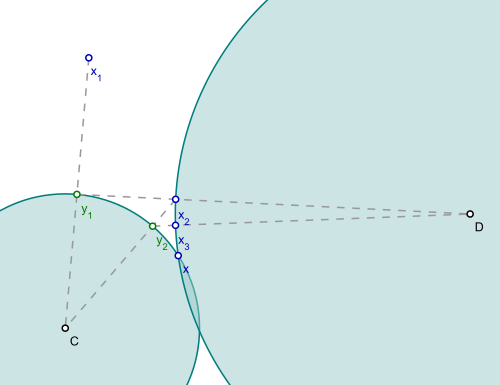

This mean that by projecting alternatively onto each constraint, we can converge to a point that satify both constraints. The original algorithm require both set to be convex, we will discuss how our variant differs from this and what kind of guarantees we can offer.

So the plan is simple:


# Björck on convs (experimental, unpublished)

This alg is a derivation of bjorck for convolutions. It ensure that the kernel get closer to orthogonality at each step, while ensuring a fixed kernel shape.

In [53]:
import torch
import torch.nn.functional as F


def compute_spectral_rescaling_conv(kernel, n_iter=1):
    if n_iter < 1:
        raise ValueError(f"n_iter must be at least equal to 1, got {n_iter}")
    effective_iter = 0
    kkt = kernel
    log_curr_norm = 0
    for _ in range(n_iter):
        padding = kkt.shape[-1] - 1
        kkt_norm = kkt.norm().detach()
        kkt = kkt / kkt_norm
        log_curr_norm = 2 * (log_curr_norm + kkt_norm.log())
        kkt = F.conv2d(kkt, kkt, padding=padding)
        effective_iter += 1
    inverse_power = 2 ** (-effective_iter)
    t = torch.abs(kkt)
    t = t.sum(dim=(1, 2, 3)).pow(inverse_power)
    norm = torch.exp(log_curr_norm * inverse_power)
    t = t * norm
    return t


def orthogonalize_kernel_beta(
    ker: torch.Tensor,
    beta_init: float = 0.5,
    beta_end: float = 0.5,
    num_iters: int = 10,
    damp=0.99,
    epsilon: float = 0.01,
) -> torch.Tensor:
    """
    Orthogonalizes a conv2d kernel with a bjorck-based update, and inlines an AOL
    1-Lipschitz (L2) per-input-channel rescale.

    Args:
        ker: conv2d kernel [outC, inC, kh, kw]
        beta_init: starting beta value
        beta_end: ending beta value
        num_iters: number of iterations
        damp: damping factor
        epsilon: small positive constant for AOL rescale stability
        padding: number of pixels to zero-pad the kernel before the loop

    Returns:
        torch.Tensor with same shape as `ker` (original shape)
    """
    assert ker.ndim == 4, "ker must be [outC, inC, kh, kw]"
    co, ci, kh, kw = ker.shape

    # ---- Delattra per-input-channel rescale ----
    ker = ker / (compute_spectral_rescaling_conv(ker, n_iter=2).max() + epsilon)

    # Update shapes for Bjork logic
    _, _, current_kh, current_kw = ker.shape
    ph, pw = current_kh - 1, current_kw - 1

    betas = torch.linspace(
        beta_init, beta_end, steps=max(1, num_iters), dtype=ker.dtype, device=ker.device
    )

    for beta in betas:
        kk = F.conv2d(ker, ker, padding=(ph, pw))
        kkk = F.conv_transpose2d(kk, ker, padding=(ph, pw))

        # Bjork update
        ker = (1.0 + beta) * damp * ker - beta * damp * kkk

    return ker

# now time to test the method

We will evaluate the method on random kernels, and explicitly construct the Block circulant matrix on small images/kernels

In [54]:
def _compute_sv_impulse_response_layer(kernel, img_shape):
    # fixing seeds for reproducibility
    layer = torch.nn.Conv2d(
        in_channels=kernel.shape[1],
        out_channels=kernel.shape[0],
        kernel_size=kernel.shape[-2:],
        padding=kernel.shape[-2] // 2,
        padding_mode="circular",
    )
    layer.weight.data = kernel
    layer.bias.data = torch.zeros(kernel.shape[0])
    torch.manual_seed(0)
    np.random.seed(0)
    with torch.no_grad():
        layer = layer.to(device)
        inputs = (
            torch.eye(img_shape[0] * img_shape[1] * img_shape[2])
            .view(
                img_shape[0] * img_shape[1] * img_shape[2],
                img_shape[0],
                img_shape[1],
                img_shape[2],
            )
            .to(device)
        )
        outputs = layer(inputs)
        outputs_reshaped = outputs.view(outputs.shape[0], -1)
        sv_max = torch.linalg.norm(outputs_reshaped, ord=2)
        sv_min = torch.linalg.norm(outputs_reshaped, ord=-2)
        fro_norm = torch.linalg.norm(outputs_reshaped, ord="fro")
        # svs = torch.linalg.svdvals(outputs.view(outputs.shape[0], -1))
        # svs = svs.cpu()
        # return svs.min(), svs.max(), svs.mean() / svs.max()
        return (
            sv_min,
            sv_max,
            fro_norm**2
            / (sv_max**2 * min(outputs_reshaped.shape[0], outputs_reshaped.shape[1])),
        )


def _plot_svs_layer(kernel, img_shape):
    # fixing seeds for reproducibility
    layer = torch.nn.Conv2d(
        in_channels=kernel.shape[1],
        out_channels=kernel.shape[0],
        kernel_size=kernel.shape[-2:],
        padding=kernel.shape[-2] // 2,
        padding_mode="circular",
    )
    layer.weight.data = kernel
    layer.bias.data = torch.zeros(kernel.shape[0])
    torch.manual_seed(0)
    np.random.seed(0)
    with torch.no_grad():
        layer = layer.to(device)
        inputs = (
            torch.eye(img_shape[0] * img_shape[1] * img_shape[2])
            .view(
                img_shape[0] * img_shape[1] * img_shape[2],
                img_shape[0],
                img_shape[1],
                img_shape[2],
            )
            .to(device)
        )
        outputs = layer(inputs)
        outputs_reshaped = outputs.view(outputs.shape[0], -1)
        sv_max = torch.linalg.norm(outputs_reshaped, ord=2)
        sv_min = torch.linalg.norm(outputs_reshaped, ord=-2)
        fro_norm = torch.linalg.norm(outputs_reshaped, ord="fro")
        svs = torch.linalg.svdvals(outputs.view(outputs.shape[0], -1))
        svs = svs.cpu()
        return svs

In [55]:
def spectral_rescale(ker, epsilon=1e-8):
    co, ci, kh, kw = ker.shape
    ph, pw = kh - 1, kw - 1
    x = ker.transpose(0, 1)  # [ci, co, kh, kw] (view)
    w = x  # same tensor/layout

    # Pad for full correlation and convolve
    x_pad = F.pad(x, (pw, pw, ph, ph))
    v = F.conv2d(x_pad, w, bias=None, stride=1, padding=0)  # [ci, ci, 2kh-1, 2kw-1]

    # Sum abs over channel+spatial, then compute inverse sqrt
    lipschitz_bounds_sq = v.abs().sum(dim=(1, 2, 3))  # [ci]
    rescale = (lipschitz_bounds_sq + epsilon).pow(-0.5)  # [ci]
    ker = ker * rescale.view(1, -1, 1, 1)
    return ker

## hyper parameters

16 channels, 8x8 images and 3x3 kernel so block circulant stays tractable.

In [56]:
from os import linesep
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import timeit
import pandas as pd


cin = 256
cout = 256

iw, ih = (3, 3)  # with circular padding result get independant with input size
kw, kh = (3, 3)
pw = (2 * kw - 1) // 2
ph = (2 * kh - 1) // 2

ker_o = torch.as_tensor(torch.randn(cout, cin, kw, kh)).to(device)

## runtime and quality evaluation

Great, the method seems to work! Let's now see how it compares in terms of runtime.

We'll start by importing efficient code to perform RKO faster than with svd.

In [57]:
def matrixizer(t):
    """
    It returns triple (f, invf, matrix_shape) for tensor <=> matrix convertion such that
        1) invf(f(t)) = t
        2) matrix_shape = f(t).shape
        3) Preconditioner for matrix f(t) has the minimum size.

    A few examples,
        1), f(t)=t.reshape([1, 1]) for t = torch.randn([])
        2), f(t)=t.reshape([1, 10]) for t = torch.randn(10)
        3), f(t)=t for t = torch.randn(2, 5)
        4), f(t)=t.reshape(6, 5) for t = torch.randn(2,3,5)
        5), f(t)=t.permute(0,1,3,2,4).reshape(42,55) for t = torch.randn(2,3,5,7,11)
    """

    def prod(arr):
        result = 1
        for a in arr:
            result *= a
        return result

    def permutations(p0):
        if len(p0) == 1:
            yield p0
        else:
            for i in range(len(p0)):
                for q in permutations(p0[:i] + p0[i + 1 :]):
                    yield (p0[i], *q)

    if t.dim() == 2:
        return (lambda u: u, lambda v: v, t.shape)
    elif t.dim() < 2:
        mtx_shape = (1, t.numel())
        return (
            lambda u, shape=mtx_shape: u.reshape(shape),
            lambda v, shape=t.shape: v.reshape(shape),
            mtx_shape,
        )
    else:
        p0, s0 = tuple(range(t.dim())), t.shape
        min_precond_size, opt_p, opt_s, opt_i = float("inf"), None, None, None
        for p in permutations(p0):
            s = tuple(s0[j] for j in p)
            for i in range(1, len(p)):
                new_size = prod(s[:i]) ** 2 + prod(s[i:]) ** 2
                if new_size < min_precond_size:
                    min_precond_size = new_size
                    opt_p, opt_s, opt_i = p, s, i

        if opt_p == p0:
            mtx_shape = (prod(s0[:opt_i]), prod(s0[opt_i:]))
            return (
                lambda u, shape=mtx_shape: u.reshape(shape),
                lambda v, shape=s0: v.reshape(shape),
                mtx_shape,
            )
        else:
            mtx_shape = (prod(opt_s[:opt_i]), prod(opt_s[opt_i:]))
            q = tuple(
                pair[1] for pair in sorted([(k, i) for (i, k) in enumerate(opt_p)])
            )
            return (
                lambda u, permute=opt_p, shape=mtx_shape: u.permute(permute).reshape(
                    shape
                ),
                lambda v, permute=q, shape=opt_s: v.reshape(shape).permute(permute),
                mtx_shape,
            )


def _matrix_muon_update(
    g32: torch.Tensor, steps: int = 6, eps: float = 1e-7
) -> torch.Tensor:
    """
    Generic tensor Muon update using matrixizer() followed by real NS5.
    """
    f, invf, _ = matrixizer(g32)
    G = f(g32)
    U = newton_schulz(G, iter=steps, epsilon=eps)
    return invf(U)

In [58]:
import argparse
import math
from dataclasses import dataclass
from typing import Dict, Tuple, List

import torch


@dataclass
class FreqMuonCfg:
    fft_size: int = 8
    ns_steps: int = 2
    eps: float = 1e-7


# Cache: which rfft2 bins must be real (v=0 and v=M/2 when M even), for each M.
_REAL_BINS_CACHE: Dict[int, torch.Tensor] = {}


def _rfft2_real_bins(M: int, device: torch.device) -> torch.Tensor:
    """
    For rfft2 output shaped [M, M//2+1], bins at v=0 (and v=M/2 if M even) are self-conjugate
    along the last axis and must be real for a real spatial signal.
    Return linear indices into flattened freq dimension F = M*(M//2+1) for those bins.
    """
    if M in _REAL_BINS_CACHE and _REAL_BINS_CACHE[M].device == device:
        return _REAL_BINS_CACHE[M]

    W = M // 2 + 1
    u = torch.arange(M, device=device)
    v_list = [0]
    if M % 2 == 0:
        v_list.append(M // 2)
    v = torch.tensor(v_list, device=device, dtype=torch.long)

    # All (u, v in {0, M/2})
    U = u[:, None].expand(M, v.numel())
    V = v[None, :].expand(M, v.numel())
    idx = (U * W + V).reshape(-1).contiguous()  # [M * (#v)]
    _REAL_BINS_CACHE[M] = idx
    return idx


def _zeropower_ns5_split_complex(
    Xre: torch.Tensor, Xim: torch.Tensor, steps: int, eps: float
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Muon-style NS5 polynomial, but operating on complex matrices represented as (Re, Im) float32.

    Inputs:
      Xre, Xim: [B, m, n] float32

    Returns:
      Qre, Qim: [B, m, n] float32  (approx polar(X) = U V^*)
    """
    assert Xre.ndim == 3 and Xim.ndim == 3
    a, b, c = (3.4445, -4.7750, 2.0315)

    # Frobenius normalize: denom = ||X||_F
    denom = torch.sqrt(
        (Xre * Xre).sum(dim=(-2, -1)) + (Xim * Xim).sum(dim=(-2, -1))
    ).clamp_min(eps)
    Xre = Xre / denom[:, None, None]
    Xim = Xim / denom[:, None, None]

    m, n = Xre.shape[-2], Xre.shape[-1]
    transposed = False
    if m > n:
        Xre = Xre.transpose(-2, -1)
        Xim = Xim.transpose(-2, -1)
        transposed = True

    for _ in range(steps):
        Xt_re_T = Xre.transpose(-2, -1)
        Xt_im_T = Xim.transpose(-2, -1)

        # A = X X^H = (R+iI)(R^T - i I^T)
        # Ar = R R^T + I I^T
        # Ai = I R^T - R I^T
        Ar = Xre @ Xt_re_T
        Ar = Ar + (Xim @ Xt_im_T)

        Ai = Xim @ Xt_re_T
        Ai = Ai - (Xre @ Xt_im_T)

        # A2 = A A
        # (Ar+iAi)^2 = (Ar Ar - Ai Ai) + i(Ar Ai + Ai Ar)
        ArAr = Ar @ Ar
        AiAi = Ai @ Ai
        Ar2 = ArAr - AiAi

        ArAi = Ar @ Ai
        AiAr = Ai @ Ar
        Ai2 = ArAi + AiAr

        # B = bA + cA2
        Br = b * Ar + c * Ar2
        Bi = b * Ai + c * Ai2

        # BX = (Br+iBi)(R+iI) = (BrR - BiI) + i(BrI + BiR)
        BrR = Br @ Xre
        BiI = Bi @ Xim
        Yre = BrR - BiI

        BrI = Br @ Xim
        BiR = Bi @ Xre
        Yim = BrI + BiR

        # X <- aX + BX
        Xre = a * Xre + Yre
        Xim = a * Xim + Yim

    if transposed:
        Xre = Xre.transpose(-2, -1)
        Xim = Xim.transpose(-2, -1)

    return Xre, Xim


def _freq_muon_conv_update_batched(g32: torch.Tensor, cfg: FreqMuonCfg) -> torch.Tensor:
    """
    g32: [P, Cout, Cin, kH, kW] float32
    returns: [P, Cout, Cin, kH, kW] float32
    Full-bin (no subsampling) frequency-domain Muon polar update on an MxM circular grid.
    """
    assert g32.ndim == 5 and g32.dtype == torch.float32
    P, Cout, Cin, kH, kW = g32.shape
    M = cfg.fft_size
    if kH > M or kW > M:
        raise ValueError(f"Kernel {kH}x{kW} > fft_size {M}. Increase --fft_size.")

    device = g32.device
    W = M // 2 + 1
    F = M * W

    # Pad to MxM (float32)
    pad = torch.zeros((P, Cout, Cin, M, M), device=device, dtype=torch.float32)
    pad[:, :, :, :kH, :kW] = g32

    # rfft2: [P, Cout, Cin, M, W] complex64 (real/imag float32)
    Khat = torch.fft.rfft2(pad, dim=(-2, -1), norm="ortho")

    # Flatten freqs: [P*F, Cout, Cin] complex64
    Kflat = Khat.permute(0, 3, 4, 1, 2).reshape(P * F, Cout, Cin)

    # Split into real/imag views (float32)
    Xre = Kflat.real
    Xim = Kflat.imag

    # Polar per frequency bin (full bins, full steps)
    Qre, Qim = _zeropower_ns5_split_complex(Xre, Xim, steps=cfg.ns_steps, eps=cfg.eps)

    # Enforce "must-be-real" bins for rfft2 (v=0 and v=M/2 if even)
    real_f = _rfft2_real_bins(M, device=device)  # indices into [F]
    base = (torch.arange(P, device=device) * F)[:, None]  # [P,1]
    real_idx = (base + real_f[None, :]).reshape(-1)  # [P * (#real_f)]
    Qim[real_idx] = 0.0

    # Write back into Kflat in-place (no clone)
    Kflat.real.copy_(Qre)
    Kflat.imag.copy_(Qim)

    # Unflatten and irfft2 back to spatial (real float32)
    Khat2 = Kflat.reshape(P, M, W, Cout, Cin).permute(0, 3, 4, 1, 2)  # [P,Cout,Cin,M,W]
    upd_pad = torch.fft.irfft2(
        Khat2, s=(M, M), dim=(-2, -1), norm="ortho"
    )  # [P,Cout,Cin,M,M]

    return upd_pad[:, :, :, :kH, :kW]

,Method,Average Time (s)
3,Muon (actual),0.000366
4,matrixizer,0.000475
5,freq-muon,0.002223
0,NS3-conv 5 it,0.003343
1,NS3-conv 10 it,0.003407
2,NS3-conv 25 it,0.005378


,Method,Average Time (s)
5,freq-muon,737.173767
4,matrixizer,744.781189
3,Muon (actual),752.416992
1,NS3-conv 10 it,756.080627
0,NS3-conv 5 it,756.328857
2,NS3-conv 25 it,757.531128


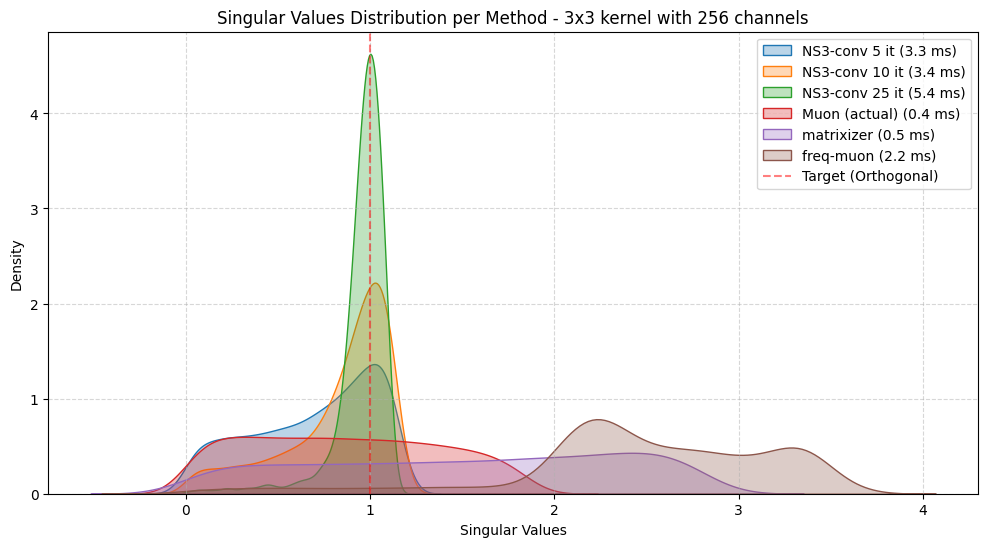

In [59]:
# Configuration
ker = ker_o.clone()
num_runs = 25
warmup = 10

timings = {}
results = {}
distances = {}

with torch.no_grad():
    for niter in [5, 10, 25]:
        for _ in range(warmup):
            orthogonalize_kernel_beta(ker, num_iters=niter)
        timings[f"NS3-conv {niter} it"] = (
            timeit.timeit(
                lambda: orthogonalize_kernel_beta(ker, num_iters=niter), number=num_runs
            )
            / num_runs
        )
        ortho_ker = orthogonalize_kernel_beta(
            ker, beta_init=.5, num_iters=niter, damp=0.99
        )
        results[f"NS3-conv {niter} it"] = _plot_svs_layer(
            ortho_ker, (cin, iw, ih)
        ).numpy()
        distances[f"NS3-conv {niter} it"] = torch.sqrt(
            torch.sum(torch.square(ortho_ker - ker))
        ).item()

    # RKO / Muon (SVD based)
    def run_rko(ker):
        # u, s, vt = torch.linalg.svd(ker.view(cout, -1), full_matrices=False)
        # Q = u @ vt / np.sqrt(kw * kh)
        Q = newton_schulz(ker.view(cout, -1))
        return Q.view(cout, cin, kw, kh)

    for _ in range(warmup):
        run_rko(ker)
    timings["Muon (actual)"] = (
        timeit.timeit(lambda: run_rko(ker), number=num_runs) / num_runs
    )
    ortho_ker = run_rko(ker)
    results["Muon (actual)"] = _plot_svs_layer(ortho_ker, (cin, iw, ih)).numpy()
    distances["Muon (actual)"] = torch.sqrt(
        torch.sum(torch.square(ortho_ker - ker))
    ).item()

    for _ in range(warmup):
        _matrix_muon_update(ker)
    timings["matrixizer"] = (
        timeit.timeit(lambda: _matrix_muon_update(ker), number=num_runs) / num_runs
    )
    ortho_ker = _matrix_muon_update(ker)
    results["matrixizer"] = _plot_svs_layer(ortho_ker, (cin, iw, ih)).numpy()
    distances["matrixizer"] = torch.sqrt(
        torch.sum(torch.square(ortho_ker - ker))
    ).item()

    cfg = FreqMuonCfg(fft_size=iw, ns_steps=5)
    for _ in range(warmup):
        _freq_muon_conv_update_batched(ker.unsqueeze(0), cfg)
    timings["freq-muon"] = (
        timeit.timeit(
            lambda: _freq_muon_conv_update_batched(ker.unsqueeze(0), cfg),
            number=num_runs,
        )
        / num_runs
    )
    ortho_ker = _freq_muon_conv_update_batched(ker.unsqueeze(0), cfg).view(
        cout, cin, kw, kh
    )
    results["freq-muon"] = _plot_svs_layer(ortho_ker, (cin, iw, ih)).numpy()
    distances["freq-muon"] = torch.sqrt(torch.sum(torch.square(ortho_ker - ker))).item()


# Display as DataFrame
df_timings = pd.DataFrame(list(timings.items()), columns=["Method", "Average Time (s)"])
df_timings = df_timings.sort_values(by="Average Time (s)")
display(df_timings)

df_distances = pd.DataFrame(
    list(distances.items()), columns=["Method", "Average Time (s)"]
)
df_distances = df_distances.sort_values(by="Average Time (s)")
display(df_distances)

plt.figure(figsize=(12, 6))
for label, svs in results.items():
    ms = df_timings[df_timings["Method"] == label]["Average Time (s)"].iloc[0] * 1000
    label = f"{label} ({ms:.1f} ms)"
    sns.kdeplot(svs, label=label, fill=True, alpha=0.3)

plt.title(
    f"Singular Values Distribution per Method - {kw}x{kh} kernel with {cin} channels"
)
plt.xlabel("Singular Values")
plt.ylabel("Density")
plt.axvline(1.0, color="red", linestyle="--", alpha=0.5, label="Target (Orthogonal)")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()

# discussion about the results:

- our algorithm seems to converge toward an orthogonal matrix, while staying on the manifold of $(k_w \times k_h)$ kernels. The alternate projection scheme does not lead to divergence.
- these experiment are done on gaussian values and the stability can be affected on other matrices (to be check)
- actual muon limit the spread of the singular values (less than $\sqrt{k_h\times k_w}$.
- runtime might be biased as it might be dominated by the matrix loading time. NS3-conv 5it theoretically have $k_wk_h$ times more flops than Muon, so the $2\times$ is likely optimistic. Also I didn't optimize the matrixizer and freq muon code so their runtime might be overestimated.
- both matrixizer and freq muon seems to exhibit a larger spread than original muon.

### what about freq muon and matrixizer?
These results are quite surprising for Freq-Muon and Matrixizer: In this context (gaussian values), the algorithm diverges from what theoretically make Muon more efficient than Adam... On the other hand, those algorithms seems to work on the cifar-10 airbench. Here is a list of hypotheses for this:
- as the cifar-10 airbench what tuned on the RKO scheme, the hyper parameters may be compliant with this deviation
- this deviation could also be a feature (meaning that the theory of Muon does not hold for convolution)
- the current experiment results does not hold in real training and performance are inverted when applied on real gradients  
- the experimental protocol is not sufficient to show a superiority

### Notes about freq-muon:
The case of freq-Muon is interesting, since the theory behind it is quite rigorous: assuming circular padding, orthogonalization in frequency domain does exactly what we want! In that sense that our algorithm alternate between partial projections where freq-muon does a single full projection onto orthogonal matrices followed by a single full projection on $(k_w \times k_h)$ kernels.
I'm not sure but does these results means that the second projection can increase $\sigma_{max}$ ?!??
Also freq-muon performs drop imaginary part to run the orthogonalisation whihc seems to have a strong importance.
